---
numbering: false
---

# 9.2. The Characteristic Polynomial

So far, we've found the eigenvalues and eigenvectors of a matrix by eyeballing them or reasoning about them geometrically, but this is not a sustainable strategy. Let's develop a more systematic approach.


---

## Deriving the Characteristic Polynomial

We're looking for combinations of scalars, $\mathbf{\lambda}$, and vectors, $\vec v$, such that

$$A \vec v = \lambda \vec v$$

In some ways, we're trying to "solve" for $\mathbf{\lambda}$ and $\vec v$ given $A$. Let's experiment a little:

$$\begin{align*} A \vec v = \lambda \vec v \\ A \vec v - \lambda \vec v = \vec 0 \\ (A - \lambda I) \vec v = \vec 0 \end{align*}$$

What the above says is that **if $\vec v$ is an eigenvector of $A$ with eigenvalue $\mathbf{\lambda}$, then $\vec v$ is in the null space of $A - \lambda I$**. But, since eigenvectors can't be the zero vector, this means that $A - \lambda I$ is not invertible, since it has a non-trivial null space!

Thinking back to [Chapter 6.2](../06_linear_transformations_and_projections/02-inverses.ipynb), we know that there are several equivalent ways to check if a matrix is not invertible. Perhaps the most computational approach is to compute its determinant; if a (square) matrix's determinant is 0, then it is not invertible, otherwise it is.

So, since $A - \lambda I$ is not invertible, its determinant must be 0!

$$A \vec v = \lambda \vec v \implies \det(A - \lambda I) = 0$$

:::{note} Definition: Characteristic Polynomial
The **characteristic polynomial** of an $n \times n$ matrix $A$ is defined as

$$p(\lambda) = \det(A - \lambda I)$$

This is a polynomial in $\mathbf{\lambda}$ of degree $n$.

The eigenvalues of $A$ are the roots of its characteristic polynomial, i.e. the values of $\mathbf{\lambda}$ that satisfy $\det(A - \lambda I) = 0$.
:::

(We won't always use the symbol $p(\lambda)$, I just introduced it above to make it clear that $\text{det}(A - \lambda I)$ is a polynomial function of $\mathbf{\lambda}$.)

Let's revisit our example $A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$.

The matrix $A - \lambda I$ is

$$A - \lambda I = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} - \lambda \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} 1 - \lambda & 2 \\ 2 & 1 - \lambda \end{bmatrix}$$

Note that $A - \lambda I$ involves subtracting $\mathbf{\lambda}$ from the diagonal elements of $A$, and leaving all other elements unchanged.

The determinant of $A - \lambda I$ is

$$\det(A - \lambda I) = (1 - \lambda)(1 - \lambda) - 2 \cdot 2 = \lambda^2 - 2\lambda + 1 - 4 = \underbrace{\lambda^2 - 2\lambda - 3}_{p(\lambda)}$$

The eigenvalues of $A$ are the values of $\mathbf{\lambda}$ where $\lambda^2 - 2\lambda - 3 = 0$.

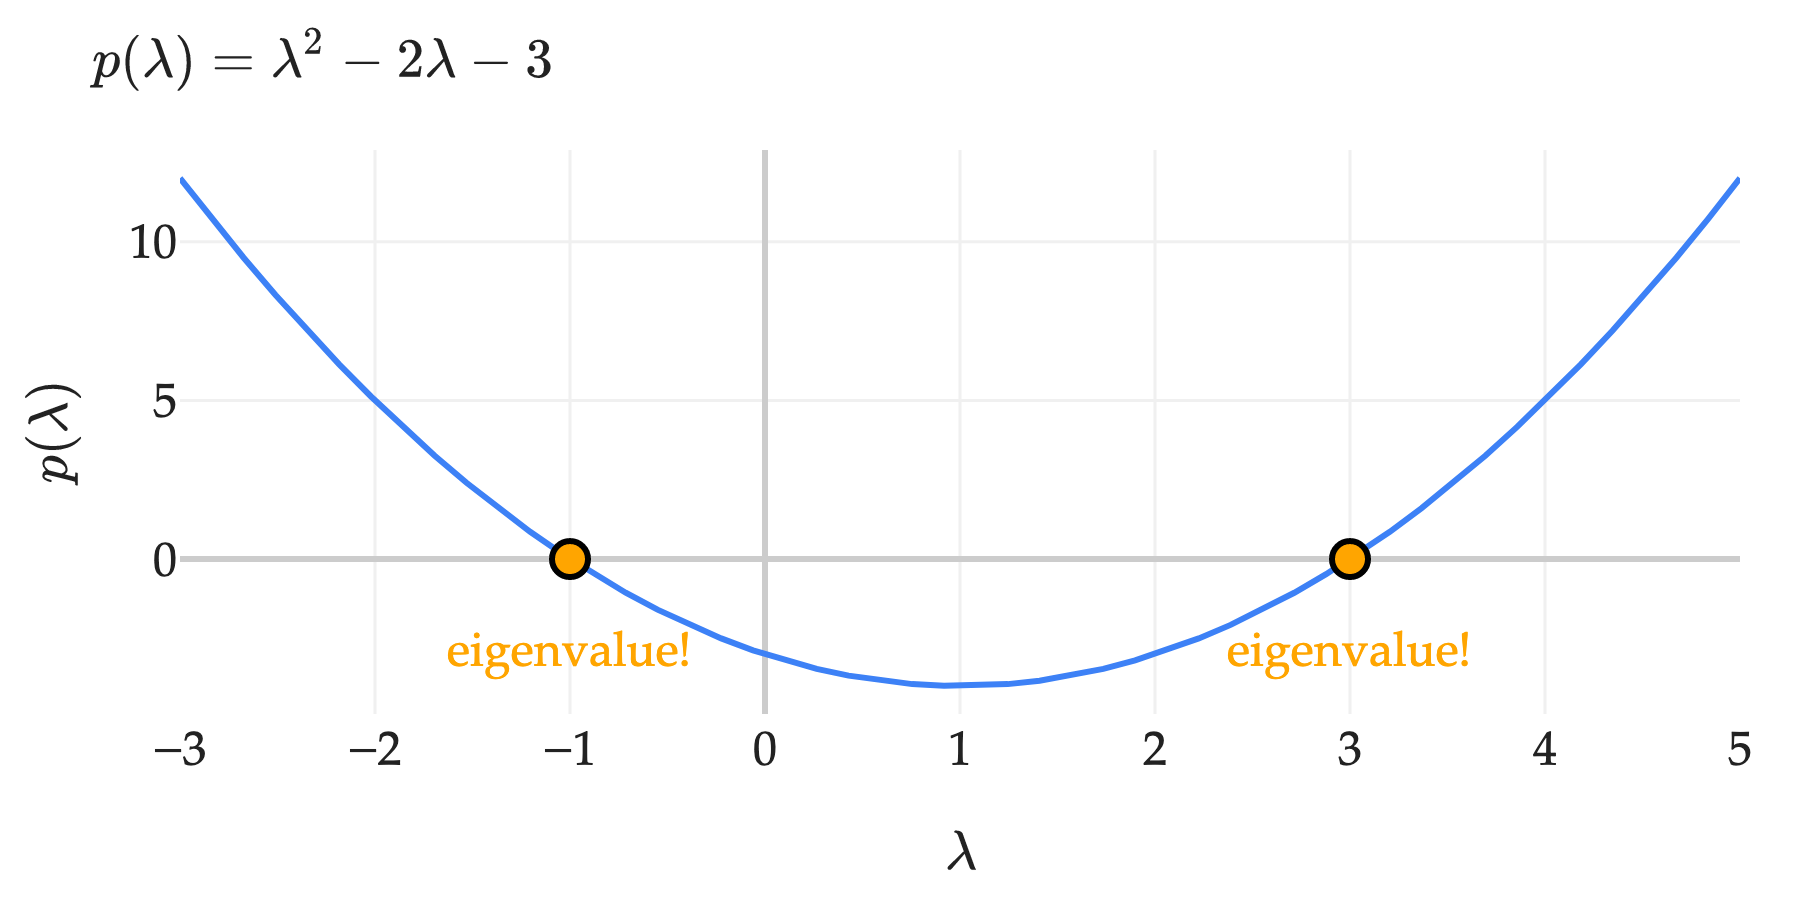

In [165]:
xs = np.linspace(-3, 5)
p = lambda x: x ** 2 - 2 * x - 3
ys = p(xs)

# Roots of the polynomial (the eigenvalues)
eigenvalues = np.array([-1, 3])
eigen_y = p(eigenvalues)

fig = go.Figure()
fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', line=dict(color='#3d81f6')))

# Add orange dots at eigenvalues
fig.add_trace(go.Scatter(
    x=eigenvalues, y=eigen_y,
    mode='markers',
    marker=dict(size=12, color='orange', line=dict(width=2, color='black')),
    name='eigenvalues'
))

# Annotate above each eigenvalue
for xv, yv in zip(eigenvalues, eigen_y):
    fig.add_annotation(
        x=xv, y=yv-4,  # slightly above the dot
        text="eigenvalue!",
        showarrow=False,
        font=dict(color="orange", size=16),
        yanchor='bottom'
    )

fig.update_layout(
    xaxis_title='$\lambda$',
    yaxis_title='$p(\lambda)$',
    width=600,
    height=300,
    font=dict(family="Palatino Linotype, Palatino, serif", size=16, color="#222"),
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    xaxis=dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=True,
        zerolinecolor="#ccc",
        zerolinewidth=2,
        linecolor=None,
        linewidth=0,
        mirror=False,
        dtick=1
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=True,
        zerolinecolor="#ccc",
        zerolinewidth=2,
        linecolor=None,
        linewidth=0,
        mirror=False
    ),
    margin=dict(l=60, r=20, t=50, b=60),
    title=r'$$p(\lambda) = \lambda^2 - 2\lambda - 3$$',
    showlegend=False
)

fig.show(scale=3, renderer='png')

(In general, we're not going to plot the characteristic polynomial each time, but I think it's useful to see once or twice to give the idea some context.)

By factoring, I can write this equation as $$(\lambda + 1)(\lambda - 3) = 0$$ which tells me that the eigenvalues of $A$ are $\lambda_1 = -1$ and $\lambda_2 = 3$. If this equation weren't factorable, I'd need to use the quadratic formula to find the eigenvalues. For now, there's no particular "ordering" to the eigenvalues, i.e. I could have said $\lambda_1 = 3$ and $\lambda_2 = -1$; all that matters is that I stay consistent throughout a particular example.

Once we find the eigenvalues by solving $p(\lambda) = 0$, we can find the eigenvectors by solving $(A - \lambda I) \vec v = \vec 0$ for each eigenvalue.

- For $\lambda_1 = -1$, we're looking for vectors $\vec v$ such that $A \vec v = -1 \vec v$, i.e. if $\vec v = \begin{bmatrix} a \\ b \end{bmatrix}$, then $$\begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} -a \\ -b \end{bmatrix}$$ (I'm using $a$ and $b$ instead of $v_1$ and $v_2$ because I'll refer to the vectors $\vec v_1$ and $\vec v_2$ in just a moment.) As a system of equations, this says $$\begin{align*} a + 2b &= -a \\ 2a + b &= -b \end{align*}$$ The first and second equations both tell us that $b = -a$. Remember, we'd expect there to be infinitely many solutions to this system, since any scalar multiple of an eigenvector is still an eigenvector. So, the "simple" solution is $\vec v_1 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$, but $\begin{bmatrix} 2 \\ -2 \end{bmatrix}$, $\begin{bmatrix} 3 \\ -3 \end{bmatrix}$, etc. are also solutions.
- For $\lambda_2 = 3$, let me introduce another way of finding the corresponding eigenvector. There's nothing wrong with the system of equations approach, but it's useful to have multiple techniques for solving problems in our toolkit. $\lambda_2 = 3$ tells us that $A \vec v = 3 \vec v$, or equivalently, $(A - 3I) \vec v = \vec 0$. So, the eigenvector we're looking for is in the null space of $A - 3I$.
    $$A - 3I = \begin{bmatrix} 1 - 3 & 2 \\ 2 & 1 - 3 \end{bmatrix} = \begin{bmatrix} -2 & 2 \\ 2 & -2 \end{bmatrix}$$
    Here, we notice that both rows of $A - 3I$ sum to 0, meaning that
    $$(A - 3I) \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$
    So, $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ is an eigenvector for $\lambda_2 = 3$.

---

## Examples

### Example: $2 \times 2$ Matrices

Find the eigenvalues and eigenvectors of $A = \begin{bmatrix} 3 & 1 \\ 2 & 4 \end{bmatrix}$.

:::{seealso} Solution
:class: dropdown

$$\begin{align*}
A-\lambda I &= \begin{bmatrix} 3 - \lambda & 1 \\ 2 & 4 - \lambda \end{bmatrix}
\\\text{det}(A-\lambda I) &= \ (3 - \lambda)(4 - \lambda)-(1 \cdot 2)
\\&= 12 -7\lambda + \lambda^2 - 2
\\&= \lambda^2 - 7\lambda +10
\\&= (\lambda-2)(\lambda-5)
\end{align*}$$
So our eigenvalues are $\lambda_1 = 2$ and $\lambda_2=5$. Next, let's find eigenvectors for them. As I did in the first example, I'll show two different techniques for finding eigenvectors.

- For $\lambda_1 = 2$, we're looking for a vector $\vec v = \begin{bmatrix} a \\ b \end{bmatrix}$ such that $A \vec v = 2 \vec v$:

    $$\begin{align*}
    A\vec v &= 2\vec v \\
    \begin{bmatrix} 3 & 1 \\ 2 & 4 \end{bmatrix} \begin{bmatrix} a \\ b \end{bmatrix} &= \begin{bmatrix} 2a \\ 2b \end{bmatrix}
    \\ 3a + b &= 2a
    \\ 2a + 4b &= 2b
    \end{align*}$$

    As expected, there are infinitely many choices for $a$ and $b$ (since both equations tell us that $b = -a$), and the resulting eigenvectors $\vec v$ all lie on the same line. So, if we let $a = 1$, then we have that $\vec v_1 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ is an eigenvector for $\lambda_1$.

- For $\lambda_2 = 5$, I'll try the null space approach, just to illustrate it once more. Again, I'm looking for a vector $\vec v$ such that $A \vec v = 5 \vec v$, or equivalently, $(A - 5I) \vec v = \vec 0$.

    $$A - 5I = \begin{bmatrix} 3 - 5 & 1 \\ 2 & 4 - 5 \end{bmatrix} = \begin{bmatrix} -2 & 1 \\ 2 & -1 \end{bmatrix}$$

    The vector $\vec v_2 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$ is orthogonal to both rows of $A - 5I$, meaning $(A - 5I) \begin{bmatrix} 1 \\ 2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$. So, $\vec v_2 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$ is an eigenvector for $\lambda_2 = 5$, though again any non-zero scalar multiple of $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$ will also be an eigenvector for $\lambda_2 = 5$.

So, $A$ has eigenvalues $\lambda_1 = 2$ and $\lambda_2 = 5$, and corresponding eigenvectors $\vec v_1 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$.
:::

### Example: Diagonal Matrices

Find the eigenvalues and eigenvectors of $A = \begin{bmatrix} 3 & 0 \\ 0 & -4 \end{bmatrix}$. What do you notice about the eigenvalues? The eigenvectors?

:::{seealso} Solution
:class: dropdown

The key is to notice that for diagonal matrices – that is, matrices where all the entries off the diagonal are 0 – the eigenvalues are simply the entries on the diagonal.

$$\begin{align*}
A-\lambda I &= \begin{bmatrix} 3 - \lambda & 0 \\ 0 &-4 - \lambda \end{bmatrix}
\\\text{det}(A-\lambda I) &= (3 - \lambda)(-4 - \lambda)
\end{align*}$$
The eigenvalues $\lambda_1 = 3$ and $\lambda_2 = -4$ are the same as the values on the diagonal! The corresponding eigenvectors are $\vec v_1 = \begin{bmatrix}1 \\ 0\end{bmatrix}$ and $\vec v_2 = \begin{bmatrix}0 \\ 1\end{bmatrix}$. Just to illustrate one of those cases out,

$$A \vec v_2 = \begin{bmatrix} 3 & 0 \\ 0 & -4 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ -4 \end{bmatrix} = -4 \begin{bmatrix} 0 \\ 1 \end{bmatrix} $$


The fact that eigenvalues and eigenvectors are so easy to find for diagonal matrices, coupled with the fact that diagonal matrices are really easy to compute powers of (e.g. $A^2$ is just the diagonal matrix with each entry squared), makes them very useful in practice.
:::

### Example: Sharing a Characteristic Polynomial

Find two **different** $2 \times 2$ matrices who have the characteristic polynomial

$$p(\lambda) = \lambda^2 - 4 \lambda + 3$$

:::{seealso} Solution
:class: dropdown

Recall that for a $2 \times 2$ matrix $A=\begin{bmatrix}a & b \\ c & d\end{bmatrix}$:
$$\begin{align*}
p(\lambda)&=\text{det}(A - \lambda I)
\\&=\begin{vmatrix}a - \lambda & b \\ c & d-\lambda \end{vmatrix}
\\&=(a-\lambda)(d-\lambda)-bc
\end{align*}$$
A simple approach to this problem is to find 2 diagonal matrices $D = \begin{bmatrix}a & 0 \\ 0 & d\end{bmatrix}$ and $D'=\begin{bmatrix}d & 0 \\ 0 & a\end{bmatrix}$. That way, all we have to do is factor $p(\lambda)$ into the form $(a-\lambda)(d-\lambda)$:
$$\begin{align*}
\lambda^2-4\lambda+3 &= (3-\lambda)(1-\lambda)
\end{align*}$$
So, our two different matrices are $D = \begin{bmatrix}3 & 0 \\ 0 & 1\end{bmatrix}$ and $D' = \begin{bmatrix}1 & 0 \\ 0 & 3\end{bmatrix}$.

There exist non-diagonal matrices with the same characteristic polynomial, too. For instance,

$$\begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$$ also has eigenvalues of $1$ and $3$, and its characteristic polynomial is also $p(\lambda) = \lambda^2 - 4\lambda + 3$. 
:::

### Example: $3 \times 3$ Matrices

Recall, if $A$ is a $3 \times 3$ matrix, like
$$A = \begin{bmatrix} {\color{3d81f6} a} & {\color{3d81f6} b} & {\color{3d81f6} c} \\ {\color{orange} d} & {\color{d81a60}e } & {\color{004d40}f } \\ {\color{orange} g} & {\color{d81a60}h } & {\color{004d40}i } \end{bmatrix}$$

then $\text{det}(A)$ is

$$\text{det}(A) = {\color{3d81f6} a} \begin{vmatrix} {\color{d81a60}e } & {\color{004d40}f } \\ {\color{d81a60}h } & {\color{004d40}i } \end{vmatrix} - {\color{3d81f6} b} \begin{vmatrix} {\color{orange} d} & {\color{004d40}f } \\ {\color{orange} g} & {\color{004d40}i } \end{vmatrix} + {\color{3d81f6} c} \begin{vmatrix} {\color{orange} d} & {\color{d81a60}e } \\ {\color{orange} g} & {\color{d81a60}h } \end{vmatrix}$$

where $| \cdot |$ denotes the determinant of the matrix.

Find the eigenvalues and eigenvectors of the **upper triangular** matrix
$$A = \begin{bmatrix} 3 & 3 & 0 \\ 0 & 1 & 5 \\ 0 & 0 & 2 \end{bmatrix}$$

What do you notice about the eigenvalues?

:::{seealso} Solution
:class: dropdown

We'll start by calculating $\text{det}(A-\lambda I)$ using the formula for the $3 \times 3$ determinant provided for us:
\begin{align*}
A-\lambda I &= 
\begin{bmatrix}
{\color{3d81f6}3 - \lambda} & {\color{3d81f6}3} & {\color{3d81f6}0} \\
{\color{orange}0} & {\color{d81a60}1-\lambda} & {\color{004d40}5} \\
{\color{orange}0} & {\color{d81a60}0} & {\color{004d40}2 - \lambda} 
\end{bmatrix} \\
\text{det}(A-\lambda I)=
&~{\color{3d81f6}(3-\lambda)} 
\begin{vmatrix}
{\color{d81a60}1-\lambda} & {\color{004d40}5} \\
{\color{d81a60}0} & {\color{004d40}2-\lambda}
\end{vmatrix}
-~ {\color{3d81f6}3}
\begin{vmatrix}
{\color{orange}0} & {\color{004d40}5} \\
{\color{orange}0} & {\color{004d40}2-\lambda}
\end{vmatrix}
+~ {\color{3d81f6}0}
\begin{vmatrix}
{\color{orange}0} & {\color{d81a60}1-\lambda} \\
{\color{orange}0} & {\color{d81a60}0}
\end{vmatrix} \\
&= (3-\lambda)\big[(1-\lambda)(2-\lambda) - 0\big]
-~ 3\big[0 - 0\big]
+~ 0\big[0 - 0\big] \\
&= (3-\lambda)(1-\lambda)(2-\lambda)
\end{align*}

So, the eigenvalues are the values along the diagonal: $\lambda_1=3$, $\lambda_2=1$, and $\lambda_3=2$. This is a convenient property of triangular matrices (which is why I've planted this example here). Next, let's find their eigenvectors.

- For $\lambda_1 = 3$, I'll do it the null space way: I'm looking for a vector in the null space of $A - 3I$. (I say "the null space way" but it's really just a different way of writing the system of equations approach, and one that can sometimes be easier to eyeball.)

    $$A - 3I = \begin{bmatrix} 0 & 3 & 0 \\ 0 & -2 & 5 \\ 0 & 0 & -1 \end{bmatrix}$$

    The zeros in the first column tell me that $(A - 3I) \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$, so $\vec v_1 = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$ is an eigenvector for $\lambda_1 = 3$. Because I have three unique eigenvalues and my matrix is $3 \times 3$, I know that this is the only possible eigenvector direction for $\lambda_1 = 3$; in [Chapter 9.4](04-multiplicities-diagonalization.ipynb), we'll run into situations where the null space of $A - 3I$ (for instance) is spanned by more than one vector, but that's not the case here.

- For $\lambda_2 = 1$, I'll do it the system of equations way: I'm looking for a vector $\vec v = \begin{bmatrix} a \\ b \\ c \end{bmatrix}$ such that $A \vec v = 1 \vec v$.

    $$\begin{align}
    A\vec v &= \vec v \\
    \begin{bmatrix} 3 & 3 & 0 \\ 0 & 1 & 5 \\ 0 & 0 & 2 \end{bmatrix} \begin{bmatrix} a \\ b \\ c \end{bmatrix} &= \begin{bmatrix} a \\ b \\ c \end{bmatrix}
    \\3a + 3b &= a
    \\b+5c &= b
    \\2c &= c
    \end{align}$$

    Once again, there are infinitely many solutions to this system, which we'd expect since there's a whole line of eigenvectors.
    - The third equation above tells us that $c = 0$.
    - Substituting that into the second equation, we have that $b + 5 \cdot 0 = b$, i.e. $b = b$, so let's treat $b$ as a free variable for now.
    - The first equation above tells us that $3a + 3b = a$, i.e. $a = -\frac{3}{2}b$.

    So, any vector of the form $\begin{bmatrix} -\frac{3}{2}b \\ b \\ 0 \end{bmatrix}$ is an eigenvector for $\lambda_2 = 1$. But we just need to find one, so let's take $b = 2$, which gives us $\vec v_2 = \begin{bmatrix} -3 \\ 2 \\ 0 \end{bmatrix}$.

- Finally, for $\lambda_3 = 2$, I'll do it the null space way.

    $$A - 2I = \begin{bmatrix} 3 - 2 & 3 & 0 \\ 0 & 1 - 2 & 5 \\ 0 & 0 & 2 - 2 \end{bmatrix} = \begin{bmatrix} 1 & 3 & 0 \\ 0 & -1 & 5 \\ 0 & 0 & 0 \end{bmatrix}$$

    I'm looking for a vector $\vec v_3 = \begin{bmatrix} a \\ b \\ c \end{bmatrix}$ in the null space of $A - 2I$, i.e. a vector whose dot product with each row of $A - 2I$ is 0. The last row of $A - 2I$ is all zeros, so I can focus my attention on the first two rows. If the first two components of $\vec v_3$ are $-3$ and $1$, then the dot product of $\vec v_3$ with the first row of $A - 2I$ is $(1)(-3) + (3)(1) = 0$, which is what I want. 
    
    Then, its dot product with the second row is $(0)(-3) + (-1)(1) + (5)(c) = -1 + 5c$, where $c$ is the last component of $\vec v_3$. For $-1 + 5c = 0$, we need $c = \frac{1}{5}$. So, one vector in the null space of $A - 2I$ – which is an eigenvector for $\lambda_3 = 2$ – is $\vec v_3 = \begin{bmatrix} -3 \\ 1 \\ \frac{1}{5} \end{bmatrix}$. To clean the numbers up a bit, I'll scale this vector by $5$, which gives us $\vec v_3 = \begin{bmatrix} -15 \\ 5 \\ 1 \end{bmatrix}$.

So, our eigenvectors for $\lambda_1=3$, $\lambda_2=1$, and $\lambda_3=2$ are $\vec v_1=\begin{bmatrix}1 \\ 0 \\ 0\end{bmatrix}$, $\vec v_2=\begin{bmatrix}-3 \\ 2 \\ 0\end{bmatrix}$, and $\vec v_3 = \begin{bmatrix}-15 \\ 5 \\ 1 \end{bmatrix}$.

:::

:::{attention} For upper triangular and lower triangular matrices, the eigenvalues are the values along the diagonal!
Recall, an upper triangular matrix has all zeros below the diagonal, and a lower triangular matrix has all zeros above the diagonal.

This comes from the fact that the determinant of an upper triangular matrix is the product of the diagonal entries, and the determinant of a lower triangular matrix is the product of the diagonal entries.

So, for example, the eigenvalues of

$$\begin{bmatrix} 10 & 3 & 2 & -50 \\ 0 & -94 & 2 & 1 \\ 0 & 0 & 0 & 3 \\ 0 & 0 & 0 & 12 \end{bmatrix}$$

are $10$, $-94$, $0$, and $12$. And, the eigenvalues of

$$
\begin{bmatrix}
2 & 0 & 0 \\
-1 & 5 & 0 \\
4 & 3 & -7
\end{bmatrix}
$$

are $2$, $5$, and $-7$.
:::

In [3]:
# When in doubt, check with numpy!
np.linalg.eig(
    np.array([
        [2, 0, 0],
        [-1, 5, 0],
        [4, 3, -7]
    ])
)


EigResult(eigenvalues=array([-7.,  5.,  2.]), eigenvectors=array([[0.        , 0.        , 0.83925433],
       [0.        , 0.9701425 , 0.27975144],
       [1.        , 0.24253563, 0.4662524 ]]))

### Number of Eigenvalues

The characteristic polynomial of an $n \times n$ matrix is a polynomial of degree $n$. A fact from algebra is that a polynomial of degree $n$ has exactly $n$ roots. The intuitive way of thinking about this is that degree $n$ polynomials can have at most $n-1$ "bends" (a line can't bend, a quadratic can bend once, a cubic can bend twice, etc.), and each time it bends, it can change directions to cross the $x$-axis again.

The issue is that some of these roots may be repeated, and some may be complex numbers, meaning that they don't actually cross the $x$-axis in the standard $xy$-plane (or in our case, the $\mathbf{\lambda}$-axis and $\lambda, p(\lambda)$-plane).

For example, the matrix $A = \begin{bmatrix} 4 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 4 \end{bmatrix}$ is diagonal, meaning its easy to read off its characteristic polynomial:

$$p(\lambda) = \det(A - \lambda I) = \begin{vmatrix} 4 - \lambda & 0 & 0 & 0 \\ 0 & 1 - \lambda & 0 & 0 \\ 0 & 0 & -\lambda & 0 \\ 0 & 0 & 0 & 4 - \lambda \end{vmatrix} = \lambda (\lambda - 1)(\lambda - 4)^2$$

This characteristic polynomial has a double root at $\lambda = 4$, a single root at $\lambda = 1$, and a single root at $\lambda = 0$. This $A$ has 3 distinct eigenvalues, but one of them, $\lambda = 2$, is repeated, and has an **algebraic multiplicity** of 2.

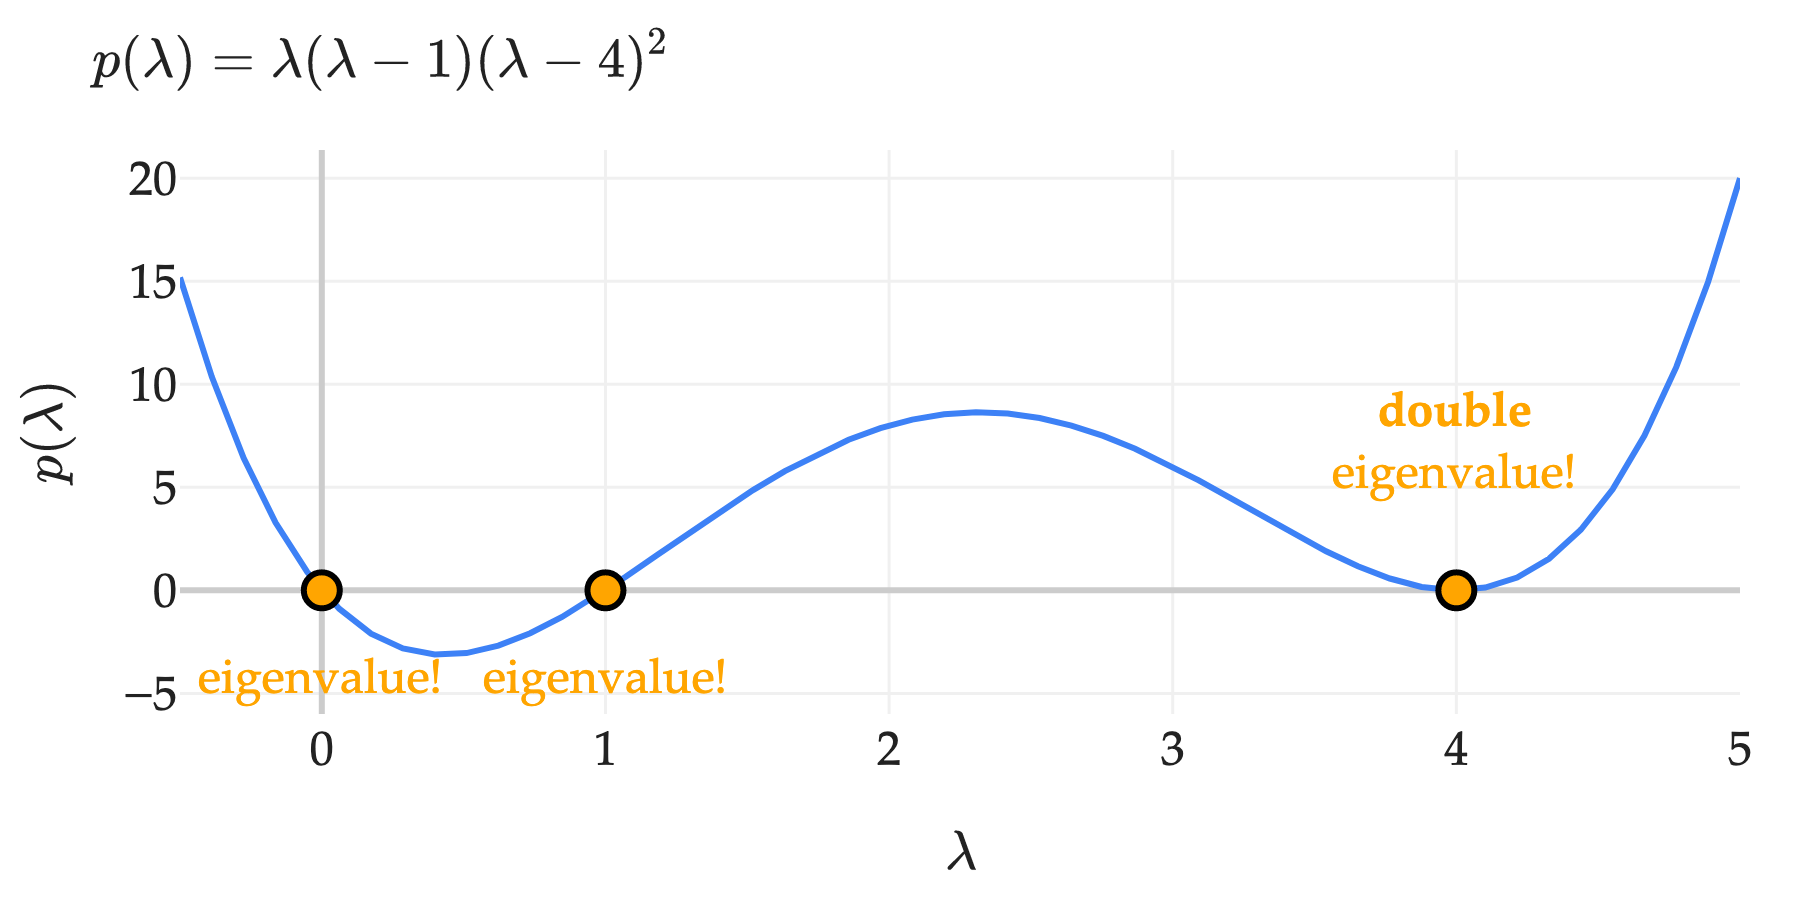

In [177]:
xs = np.linspace(-0.5, 5)
p = lambda x: (x - 4)**2 * (x - 1) * x
ys = p(xs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', line=dict(color='#3d81f6')))

eigenvalues = np.array([0, 1, 4])
eigen_y = p(eigenvalues)

# Add orange dots at eigenvalues
fig.add_trace(go.Scatter(
    x=eigenvalues, y=eigen_y,
    mode='markers',
    marker=dict(size=12, color='orange', line=dict(width=2, color='black')),
    name='eigenvalues'
))

# Annotate above each eigenvalue
for xv, yv in zip(eigenvalues, eigen_y):
    fig.add_annotation(
        x=xv, y=yv + (-6 if xv < 4 else + 4),  # slightly above the dot
        text="eigenvalue!" if xv < 4 else r"<b>double</b><br>eigenvalue!",
        showarrow=False,
        font=dict(color="orange", size=16),
        yanchor='bottom'
    )


fig.update_layout(
    xaxis_title='$\lambda$',
    yaxis_title='$p(\lambda)$',
    width=600,
    height=300,
    font=dict(family="Palatino Linotype, Palatino, serif", size=16, color="#222"),
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    xaxis=dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=True,
        zerolinecolor="#ccc",
        zerolinewidth=2,
        linecolor=None,
        linewidth=0,
        mirror=False
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=True,
        zerolinecolor="#ccc",
        zerolinewidth=2,
        linecolor=None,
        linewidth=0,
        mirror=False
    ),
    margin=dict(l=60, r=20, t=50, b=60),
    title=r'$$p(\lambda) = \lambda (\lambda - 1)(\lambda - 4)^2$$',
    showlegend=False
)

fig.show(scale=3, renderer='png')

As another example, the matrix $A = \begin{bmatrix} 3 & -4 \\ 4 & 3 \end{bmatrix}$ has the characteristic polynomial

$$p(\lambda) = \begin{vmatrix} 3 - \lambda & -4 \\ 4 & 3 - \lambda \end{vmatrix} = (\lambda - 3)^2 + 16$$

I can expand this out to get $\lambda^2 - 6\lambda + 25$, but in a case like this I think the above form is more telling. Visually, $p(\lambda)$ here is a parabola that sits entirely above the $\mathbf{\lambda}$-axis, meaning it has no real roots, so $A$ has no real eigenvalues.

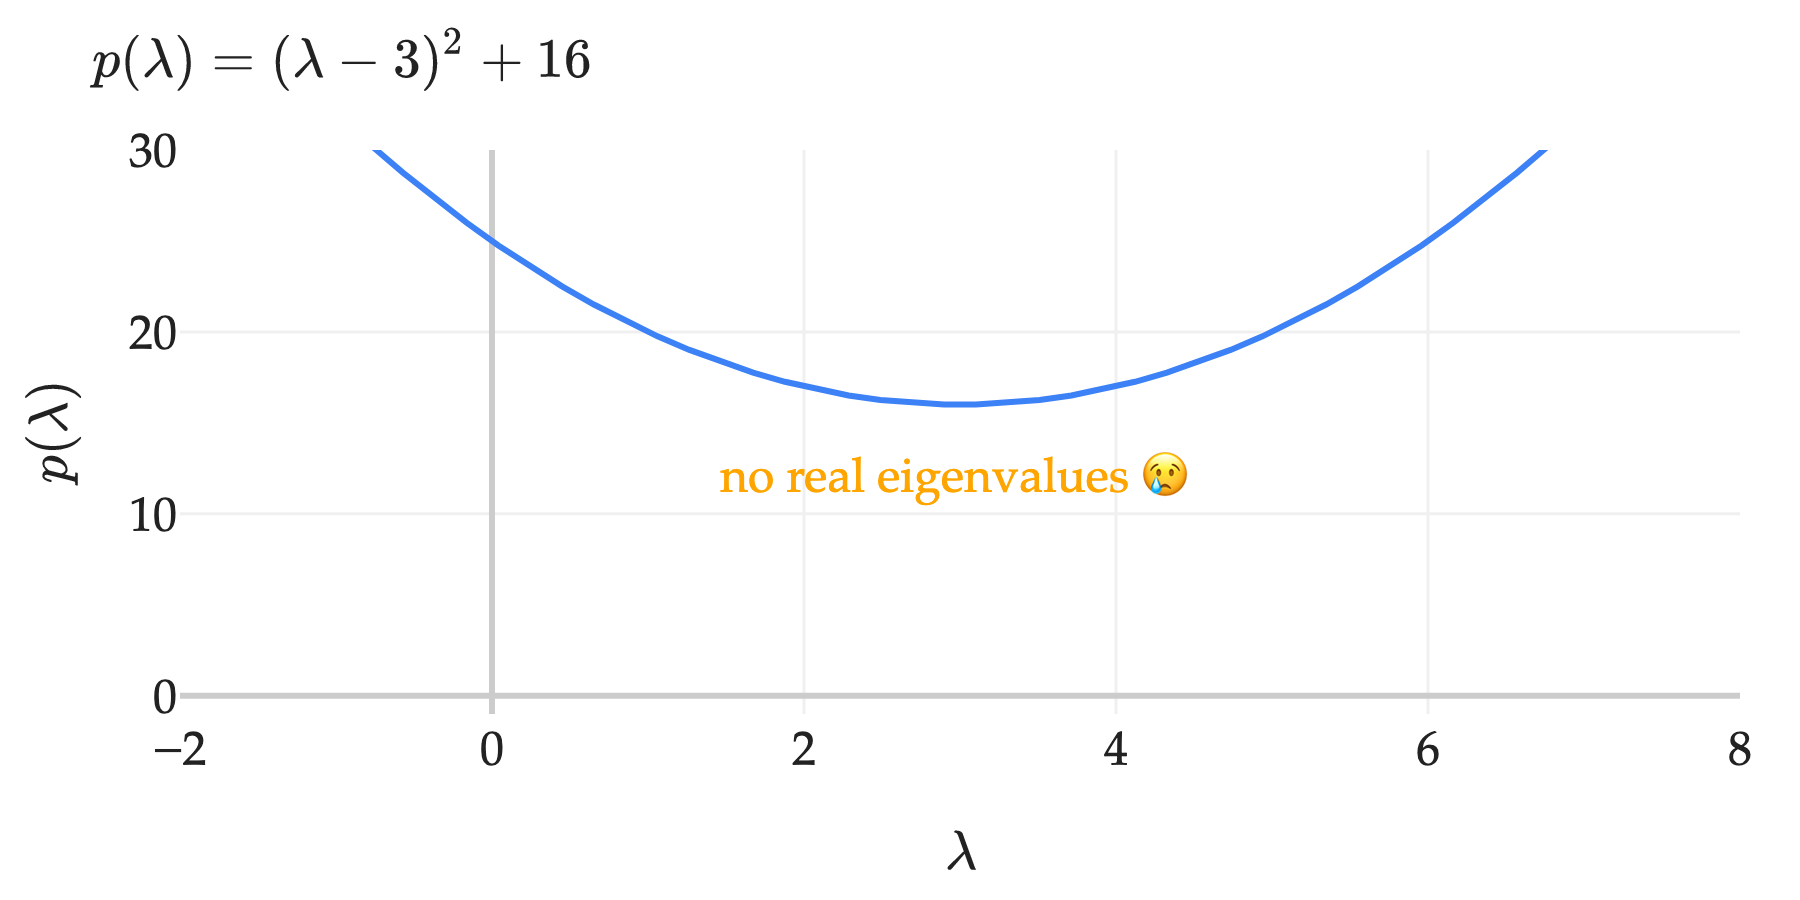

In [197]:
xs = np.linspace(3-5, 3+5)
p = lambda x: (x - 3)**2 + 16
ys = p(xs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', line=dict(color='#3d81f6')))

# eigenvalues = np.array([0, 1, 4])
# eigen_y = p(eigenvalues)

# # Add orange dots at eigenvalues
# fig.add_trace(go.Scatter(
#     x=eigenvalues, y=eigen_y,
#     mode='markers',
#     marker=dict(size=12, color='orange', line=dict(width=2, color='black')),
#     name='eigenvalues'
# ))

# # Annotate above each eigenvalue
# for xv, yv in zip(eigenvalues, eigen_y):
#     fig.add_annotation(
#         x=xv, y=yv + (-6 if xv < 4 else + 4),  # slightly above the dot
#         text="eigenvalue!" if xv < 4 else r"<b>double</b><br>eigenvalue!",
#         showarrow=False,
#         font=dict(color="orange", size=16),
#         yanchor='bottom'
#     )

fig.add_annotation(
    x=3, y=10,
    text='no real eigenvalues 😢',
    showarrow=False,
    font=dict(color="orange", size=16),
    yanchor='bottom'
)


fig.update_layout(
    xaxis_title='$\lambda$',
    yaxis_title='$p(\lambda)$',
    width=600,
    height=300,
    font=dict(family="Palatino Linotype, Palatino, serif", size=16, color="#222"),
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    xaxis=dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=True,
        zerolinecolor="#ccc",
        zerolinewidth=2,
        linecolor=None,
        linewidth=0,
        mirror=False
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=True,
        zerolinecolor="#ccc",
        zerolinewidth=2,
        linecolor=None,
        linewidth=0,
        mirror=False,
        range=[-1, 30]
    ),
    margin=dict(l=60, r=20, t=50, b=60),
    title=r'$$p(\lambda) = (\lambda - 3)^2 + 16$$',
    showlegend=False
)

fig.show(scale=3, renderer='png')

It should not be all that surprising that $A = \begin{bmatrix} 3 & -4 \\ 4 & 3 \end{bmatrix}$ has no real eigenvalues. $A$ is a rotation matrix, scaled by a factor of 5:

$$A = \begin{bmatrix} 3 & -4 \\ 4 & 3 \end{bmatrix} = 5 \begin{bmatrix} \frac{3}{5} & -\frac{4}{5} \\ \frac{4}{5} & \frac{3}{5} \end{bmatrix} = 5 \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}$$

where $\theta = \cos^{-1}\left(\frac{3}{5}\right)$. This matrix rotates vectors by $\mathbf{\theta}$ radians counterclockwise, which means that no real-valued vector will remain in the same direction after being multiplied by $A$. In the $2 \times 2$ case, the only way to get a real-valued eigenvalue out of a rotation matrix is if the matrix rotates by an integer multiple of $\mathbf{\pi}$ radians (180 degrees), which either corresponds to reflecting/negating the vector (like in $\begin{bmatrix} -1 & 0 \\ 0 & -1 \end{bmatrix}$) or returning back the same vector itself (like in $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$, the identity matrix, which can be thought of as a rotation by $2 \pi$).

The solutions to $p(\lambda) = (\lambda - 3)^2 + 16 = 0$ are the complex numbers $\lambda = 3 + 4i$ and $\lambda = 3 - 4i$, again where $i$ is the imaginary unit, defined by $i^2 = -1$. The corresponding eigenvectors are complex too, and we won't worry about finding them. (If you're familiar with complex numbers, you might recognize these eigenvalues as $5e^{i\theta}$ and $5e^{-i\theta}$, where $\theta = \cos^{-1}\left(\frac{3}{5}\right)$. This comes from Euler's formula, $e^{i\theta} = \cos \theta + i \sin \theta$.)

### Trace and Determinant

As a final example, consider the arbitrary $2 \times 2$ matrix

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$$

Its characteristic polynomial is

$$p(\lambda) = \begin{vmatrix} a - \lambda & b \\ c & d - \lambda \end{vmatrix} = (a - \lambda)(d-\lambda) - bc = \lambda^2 - (a + d)\lambda + ad-bc$$

The coefficient on $\mathbf{\lambda}$ is $-(a + d)$, which is the negative of the **sum of the diagonal entries of $A$**. A term often used to refer to the sum of the diagonal entries of a matrix is its **trace**, $\text{trace}(A)$. And, the constant term of $p(\lambda)$ above is just $\text{det}(A)$! For $2 \times 2$ matrices, this says that the characteristic polynomial is of the form

$$p(\lambda) = \lambda^2 - \text{trace}(A) \lambda + \text{det}(A)$$

For example, consider $A = \begin{bmatrix} 3 & 1 \\ 7 & 9 \end{bmatrix}$. The fact above says that $A$'s characteristic polynomial is

$$p(\lambda) = \lambda^2 - (3 + 9)\lambda + (3 \cdot 9 - 1 \cdot 7) = \lambda^2 - 12\lambda + 20$$

which, with enough practice, is a calculation you might be able to do in your head. But, this gives way to a more general fact, that is true for any $n \times n$ matrix.

:::{attention} Eigenvalues multiply to the determinant and add to the trace!

That is, the product of the eigenvalues of an $n \times n$ matrix is equal to its determinant, $\text{det}(A)$, and the sum of the eigenvalues of a matrix is equal to the sum of the diagonal, $\text{trace}(A)$. 

These are two conditions, and if I have a matrix that's larger than $2 \times 2$, they're not enough to determine the eigenvalues. But, they're helpful in indicating whether the eigenvalues you've found are correct or not.
:::

**Example 1**: $A = \begin{bmatrix} 3 & 1 \\ 7 & 9 \end{bmatrix}$'s eigenvalues add up to $3 + 9 = 12$ and multiply to $\text{det}(A) = 3 \cdot 9 - 1 \cdot 7 = 20$. This gives me a quick way of figuring out that $A$'s eigenvalues are $10$ and $2$.

**Example 2**: $A = \begin{bmatrix} 0.5 & 0.5 & 0 \\ 0.4 & 0.3 & 0.3 \\ 0 & 0.5 & 0.5 \end{bmatrix}$ has an eigenvalue of $1$, corresponding to the eigenvector $\begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$, since the sum of each row of $A$ is $1$. Let $\lambda_2$ and $\lambda_3$ be the other two eigenvalues. The trace fact tells me that $$1 + \lambda_2 + \lambda_3 = 0.5 + 0.3 + 0.5 = 1.3 \implies \lambda_2 + \lambda_3 = 0.3$$ and the determinant fact tells me that
\begin{align*}
    1 \cdot \lambda_2 \cdot \lambda_3
    &= \begin{vmatrix}
        0.5 & 0.5 & 0 \\
        0.4 & 0.3 & 0.3 \\
        0 & 0.5 & 0.5
    \end{vmatrix} \\
    &= 0.5 (0.3 \cdot 0.5 - 0.3 \cdot 0.5) - 0.5 (0.4 \cdot 0.5 - 0.3 \cdot 0) + 0 (0.4 \cdot 0.5 - 0.3 \cdot 0) \\
    &= -0.5 \cdot 0.4 \cdot 0.5
    &= -0.1
\end{align*}

In other words, the other two eigenvalues sum to $0.3$ and multiply to $-0.1$. This sounds like a job for $0.5$ and $-0.2$, which are indeed the other two eigenvalues of $A$ (other than $1$).

**Example 3**: $A = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$ has a determinant of $1 \cdot 4 - 2 \cdot 2 = 0$, which means that its eigenvalues multiply to $0$, which is another reminder that $A$ has an eigenvalue of $0$. The trace fact tells me that the other eigenvalue $\lambda_2$ must satisfy $1 + 4 = 0 + \lambda_2$, so $\lambda_2 = 5$.

---

## Key Takeaways

Let's summarize the key ideas from both this section and the last.

Suppose $A$ is an $n \times n$ matrix.

1. $\mathbf{\lambda}$ is an eigenvalue of $A$, corresponding to the eigenvector $\vec v$, if

    $$A \vec v = \lambda \vec v$$

    The English interpretation of this is that $\vec v$ is an eigenvector of $A$ if, when multiplied by $A$, $\vec v$ still points in the same direction, and is just stretched by a factor of $\mathbf{\lambda}$.

2. An $n \times n$ matrix $A$ has exactly $n$ eigenvalues. Some of these may be complex, and some of these may be repeated, but all of them are roots to the **characteristic polynomial** of $A$,

$$p(\lambda) = \det(A - \lambda I)$$

3. A quick way to check if you've found the right eigenvalues is that
- The product of the eigenvalues of $A$ is equal to $\det(A)$, i.e. $\lambda_1 \lambda_2 \cdots \lambda_n = \det(A)$.
- The sum of the eigenvalues of $A$ is equal to the trace of $A$, which is the sum of the diagonal elements of $A$.

4. 0 is an eigenvalue of $A$ if and only if $A$ is not invertible.

5. If $\mathbf{\lambda}$ is an eigenvalue of $A$ with eigenvector $\vec v$, then $\mathbf{\lambda}^k$ is an eigenvalue of $A^k$ with **the same** eigenvector $\vec v$.